In [ ]:
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import random
import pandas as pd


class MyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transfrom = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        img_path = self.image_paths[index]
        try:
            img = Image.open(img_path).convert('RGB')
            label = self.labels[index]
            if self.transfrom:
                img = self.transfrom(img)
            return img, label
        except Exception as e:
            print("发生错误：", e)
            new_idx = random.randint(0, len(self)-1)
            return self.__getitem__(new_idx)

In [ ]:
csv = pd.read_csv('dataset/labels.csv')

In [ ]:
img_paths = csv['path']
labels = csv['label']

In [ ]:

my_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])


mydataset = MyDataset(image_paths=img_paths,
                      labels=labels, transform=my_transforms)

myloader = DataLoader(
    dataset=mydataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [ ]:
data_iter = iter(myloader)
images, labels = next(data_iter)

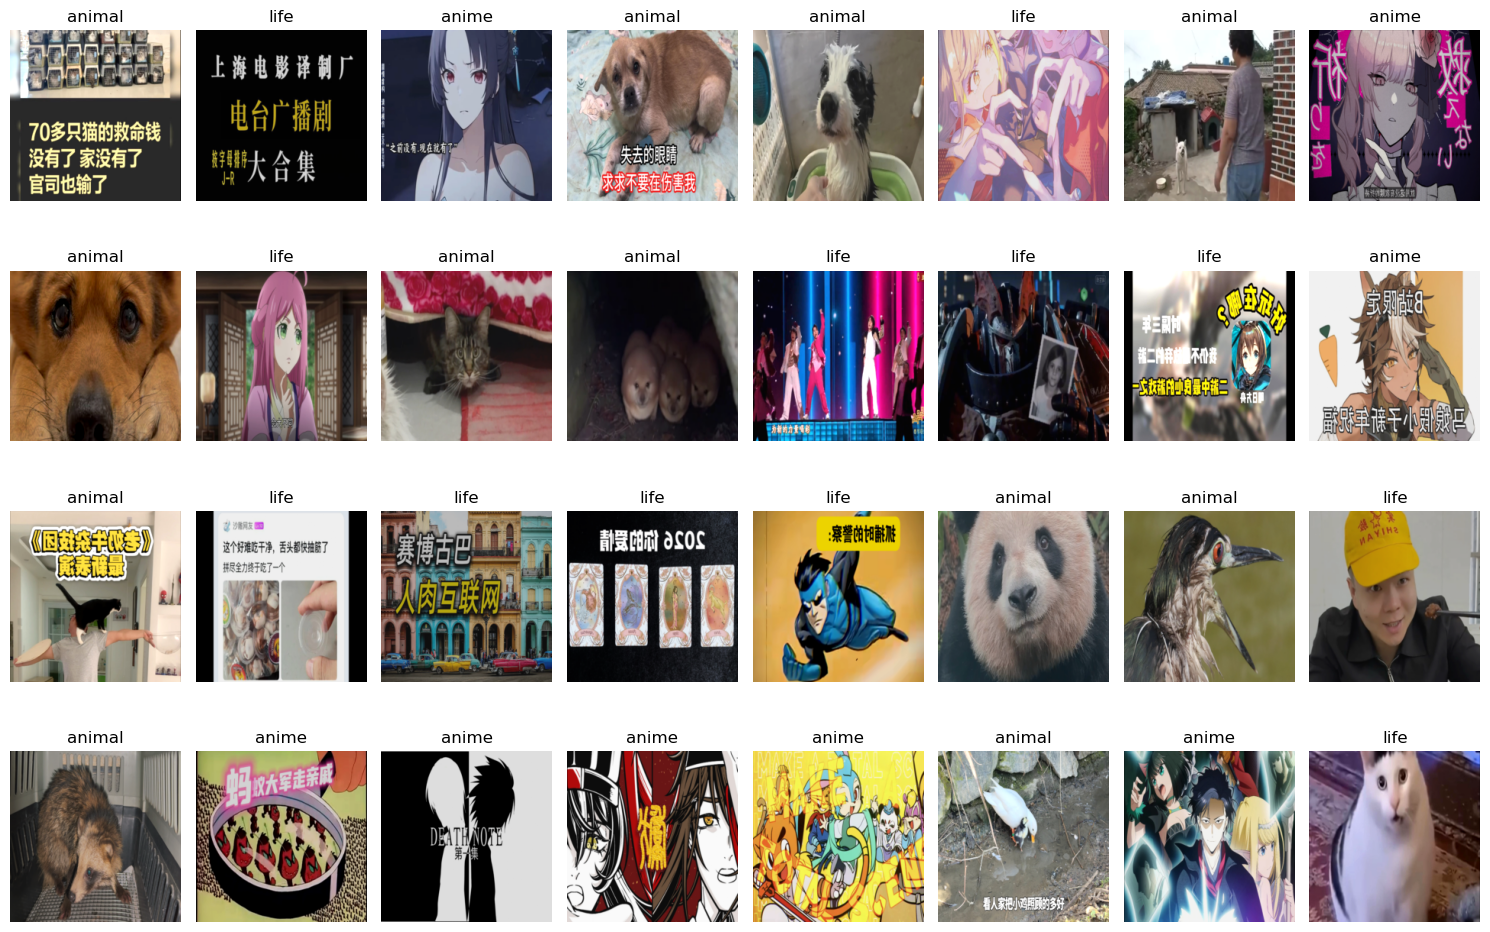

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15, 10))
for i in range(32):
    ax = fig.add_subplot(4, 8, i+1)
    img = images[i].numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(labels[i])
    ax.axis('off')
plt.tight_layout()

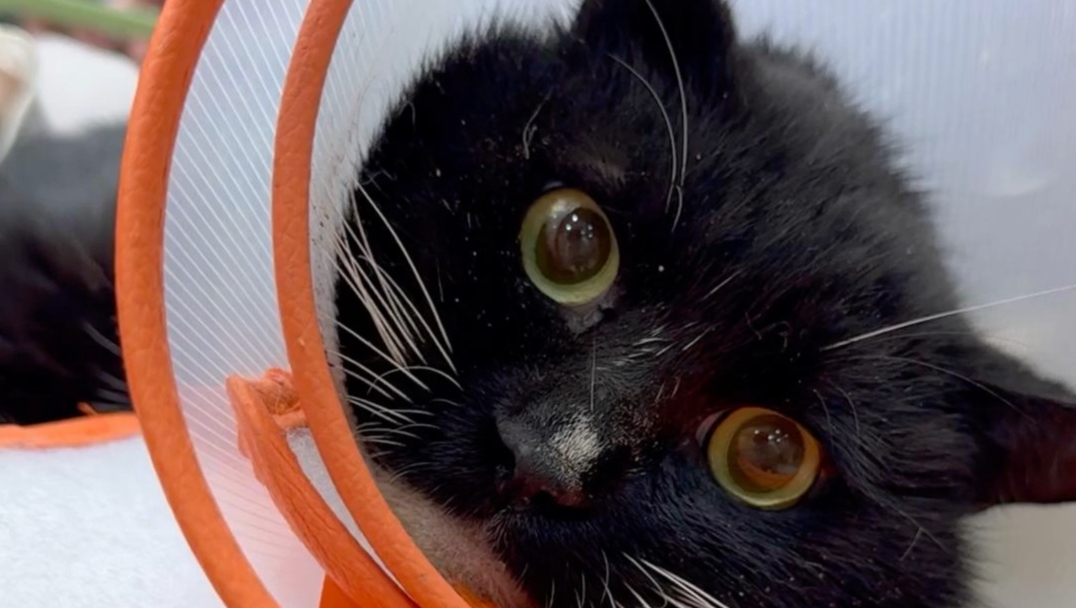

In [ ]:
img = Image.open(img_paths[5]).convert('RGB')
img

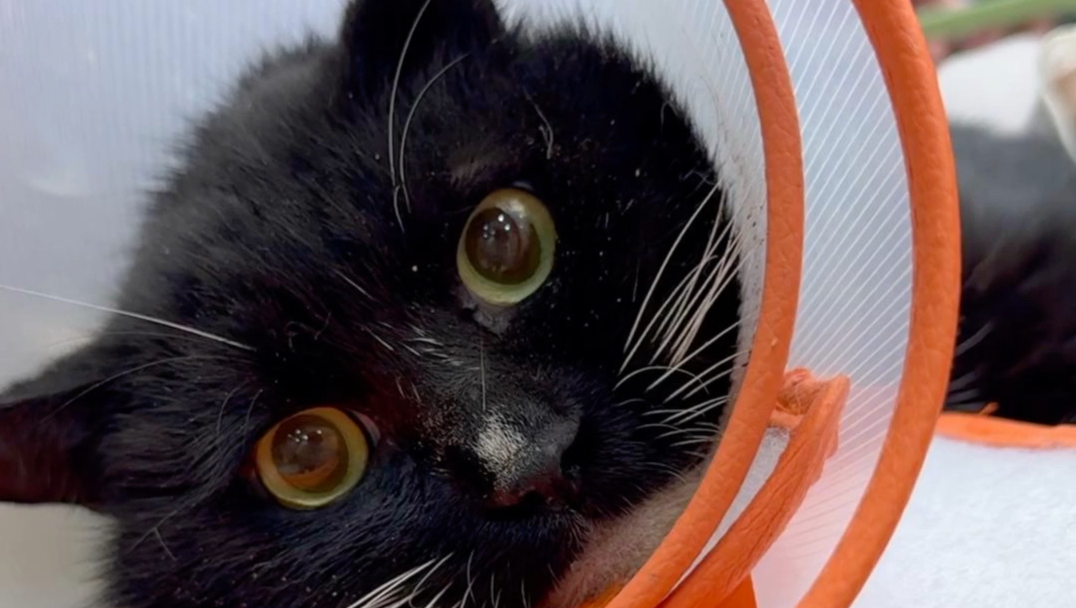

In [9]:
transforms.RandomHorizontalFlip(1)(img)

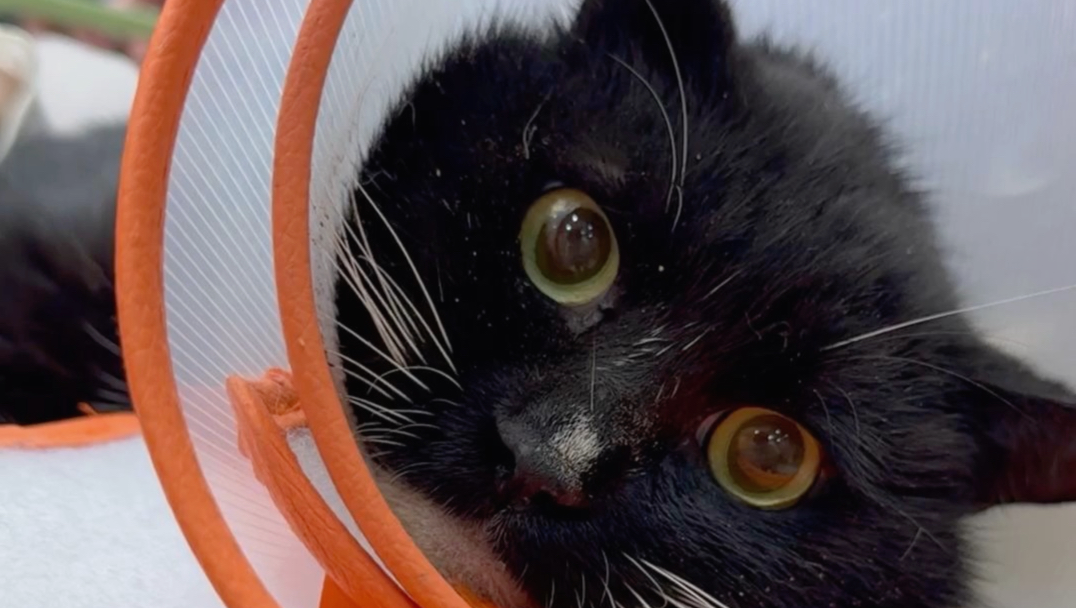

In [ ]:
transforms.ColorJitter(0.2, 0.2)(img)